# EIP-8038 SLOAD/SSTORE Model Fit Investigation

The fitted NNLS models for SLOAD and SSTORE from the `estimate_8038_repricings.py` pipeline produce poor fits.
This notebook investigates whether the problem lies in the **benchmarks** or in the **processing/modeling code**.

**Two benchmark test types** are available for SLOAD/SSTORE:
1. `test_storage_sload_benchmark` / `test_sstore_variants` — parametric benchmarks using `access_warm` flag
2. `test_storage_access_*` — separate cold/warm test variants (e.g., `test_storage_access_cold_sload`)

We investigate both.

In [1]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import linregress

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2", rc={"figure.dpi": 150, "axes.titlesize": 13})

# Directories
repo_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_dir = os.path.join(repo_dir, "src")
sys.path.append(src_dir)

from data import extract_param_values

In [2]:
# Load the exported data
data_dir = os.path.join(
    repo_dir, "reports", "eip-8038", "runtime_estimation", "2026-01-26_2026-02-19"
)

mainnet_df = pd.read_csv(os.path.join(data_dir, "gas_bench_data_mainnet.csv"))
devnet_df = pd.read_csv(os.path.join(data_dir, "gas_bench_data_perf_devnet_2.csv"))
results_df = pd.read_csv(os.path.join(data_dir, "results_mainnet.csv"))

# Clean up anming for test_storage_access
mainnet_df["test_name"] = np.where(
    mainnet_df["test_name"].str.contains("test_storage_access"),
    "test_storage_access",
    mainnet_df["test_name"],
)
devnet_df["test_name"] = np.where(
    devnet_df["test_name"].str.contains("test_storage_access"),
    "test_storage_access",
    devnet_df["test_name"],
)
# Filter opcodes
mainnet_df = mainnet_df[mainnet_df["test_opcode"].isin(["SSTORE", "SLOAD"])]


print(f"Mainnet: {len(mainnet_df)} rows, Devnet: {len(devnet_df)} rows")
print(f"Unique opcodes: {mainnet_df['test_opcode'].nunique()}")

Mainnet: 11535 rows, Devnet: 208674 rows
Unique opcodes: 2


## 1. Data Overview: SLOAD and SSTORE across all test types

In [3]:
# All SLOAD and SSTORE rows
sload_df = mainnet_df[mainnet_df["test_opcode"] == "SLOAD"].copy()
sstore_df = mainnet_df[mainnet_df["test_opcode"] == "SSTORE"].copy()

for label, df in [("SLOAD", sload_df), ("SSTORE", sstore_df)]:
    print(f"=== {label} ===")
    print(f"Total rows: {len(df)}")
    print(f"Test names: {sorted(df['test_name'].unique())}")
    print(f"Clients: {df['client_name'].value_counts().to_dict()}")
    for tn in sorted(df["test_name"].unique()):
        sub = df[df["test_name"] == tn]
        print(f"  {tn}: {len(sub)} rows, params={sorted(sub['test_params'].dropna().unique())}")
        print(f"    opcount: {sub['opcount'].min():.0f}-{sub['opcount'].max():.0f} (NaN: {sub['opcount'].isna().sum()})")
    print()

=== SLOAD ===
Total rows: 2700
Test names: ['test_storage_access', 'test_storage_sload_benchmark']
Clients: {'nethermind': 1100, 'besu': 1100, 'geth': 500}
  test_storage_access: 1020 rows, params=['cold_0', 'cold_1']
    opcount: 14252-2933430 (NaN: 0)
  test_storage_sload_benchmark: 1680 rows, params=['cold_0', 'cold_1']
    opcount: 14038-147282 (NaN: 0)

=== SSTORE ===
Total rows: 8835
Test names: ['test_sstore_variants', 'test_storage_access']
Clients: {'nethermind': 3720, 'besu': 3720, 'geth': 1395}
  test_sstore_variants: 6795 rows, params=['new_0-update_0-cold_0', 'new_0-update_0-cold_1', 'new_0-update_1-cold_0', 'new_0-update_1-cold_1', 'new_1-update_0-cold_0', 'new_1-update_0-cold_1', 'new_1-update_1-cold_0', 'new_1-update_1-cold_1']
    opcount: 1353-146921 (NaN: 0)
  test_storage_access: 2040 rows, params=['cold_0-new_0-update_1', 'cold_0-new_1-update_1', 'cold_1-new_0-update_1', 'cold_1-new_1-update_1']
    opcount: 6-54 (NaN: 0)



In [15]:
mainnet_df.groupby(["test_name", "test_params"])["block_limit_million"].agg(["min", "max"]).reset_index()

,test_name,test_params,min,max
0,test_sstore_variants,new_0-update_0-cold_0,30,300
1,test_sstore_variants,new_0-update_0-cold_1,30,300
2,test_sstore_variants,new_0-update_1-cold_0,30,300
3,test_sstore_variants,new_0-update_1-cold_1,30,300
4,test_sstore_variants,new_1-update_0-cold_0,30,300
5,test_sstore_variants,new_1-update_0-cold_1,30,300
6,test_sstore_variants,new_1-update_1-cold_0,30,300
7,test_sstore_variants,new_1-update_1-cold_1,30,300
8,test_storage_access,cold_0,30,300
9,test_storage_access,cold_0-new_0-update_1,30,300


## 2. Do tests provide cold/warm differentiation?

The `test_storage_access` tests come in explicit cold/warm variants via the **test name**
(e.g., `test_storage_access_cold_sload` vs `test_storage_access_warm_sload`). These test names are mapped to the `cold_0`, `cold_1` parameters.

In [4]:
def analyze_cold_warm_opcounts(df, opcode_label):
    """Analyze cold/warm opcount ratios for a given opcode subset."""
    op_df = df[df["test_opcode"] == opcode_label].copy()
    if len(op_df) == 0:
        print(f"No {opcode_label} data found.")
        return None

    # Extract cold param
    op_df["cold"] = op_df["test_params"].apply(lambda x: extract_param_values(str(x), "cold"))
    
    # Show opcounts by test_name, cold, and block_limit
    for tn in sorted(op_df["test_name"].unique()):
        tn_df = op_df[op_df["test_name"] == tn]
        print(f"\n--- {tn} ({opcode_label}) ---")
        opcounts = tn_df[["cold", "block_limit_million", "opcount"]].drop_duplicates()
        
        for cold_val in sorted(opcounts["cold"].dropna().unique()):
            sub = opcounts[opcounts["cold"] == cold_val].sort_values("opcount")
            label = "warm" if cold_val == "0" else "cold"
            print(f"  cold={cold_val} ({label}): opcount {sub['opcount'].min():.0f} - {sub['opcount'].max():.0f} "
                  f"({sub['opcount'].nunique()} unique, NaN: {tn_df[tn_df['cold']==cold_val]['opcount'].isna().sum()})")
        
        # Compute ratio if both variants exist
        c0 = opcounts[opcounts["cold"] == "0"]["opcount"].dropna()
        c1 = opcounts[opcounts["cold"] == "1"]["opcount"].dropna()
        if len(c0) > 0 and len(c1) > 0:
            ratio = c0.max() / c1.max()
            gas_warm = 300e6 / c0.max() if c0.max() > 0 else np.nan
            gas_cold = 300e6 / c1.max() if c1.max() > 0 else np.nan
            print(f"  Max opcount ratio (warm/cold): {ratio:.2f}x (expected ~21x)")
            print(f"  Implied gas/op: warm={gas_warm:.0f}, cold={gas_cold:.0f}")
    return op_df

print("=" * 60)
print("SLOAD opcount analysis by test type")
print("=" * 60)
sload_analyzed = analyze_cold_warm_opcounts(mainnet_df[mainnet_df["test_opcode"] == "SLOAD"], "SLOAD")

print("\n" + "=" * 60)
print("SSTORE opcount analysis by test type")
print("=" * 60)
sstore_analyzed = analyze_cold_warm_opcounts(mainnet_df[mainnet_df["test_opcode"] == "SSTORE"], "SSTORE")

SLOAD opcount analysis by test type

--- test_storage_access (SLOAD) ---
  cold=0 (warm): opcount 293293 - 2933430 (10 unique, NaN: 0)
  cold=1 (cold): opcount 14252 - 142549 (10 unique, NaN: 0)
  Max opcount ratio (warm/cold): 20.58x (expected ~21x)
  Implied gas/op: warm=102, cold=2105

--- test_storage_sload_benchmark (SLOAD) ---
  cold=0 (warm): opcount 14725 - 147282 (10 unique, NaN: 0)
  cold=1 (cold): opcount 14038 - 140401 (10 unique, NaN: 0)
  Max opcount ratio (warm/cold): 1.05x (expected ~21x)
  Implied gas/op: warm=2037, cold=2137

SSTORE opcount analysis by test type

--- test_sstore_variants (SSTORE) ---
  cold=0 (warm): opcount 1358 - 146921 (67 unique, NaN: 0)
  cold=1 (cold): opcount 1353 - 134055 (64 unique, NaN: 0)
  Max opcount ratio (warm/cold): 1.10x (expected ~21x)
  Implied gas/op: warm=2042, cold=2238

--- test_storage_access (SSTORE) ---
  cold=0 (warm): opcount 6 - 54 (10 unique, NaN: 0)
  cold=1 (cold): opcount 6 - 54 (10 unique, NaN: 0)
  Max opcount ratio 

The following tests don't seem to provide differentiation between cold and warm:
- test_storage_sload_benchmark 
- test_sstore_variants
- test_storage_access (only SSTORE)

## 4. Runtime patterns by test type and client

Compare runtime vs opcount for all SLOAD/SSTORE tests, colored by cold/warm.

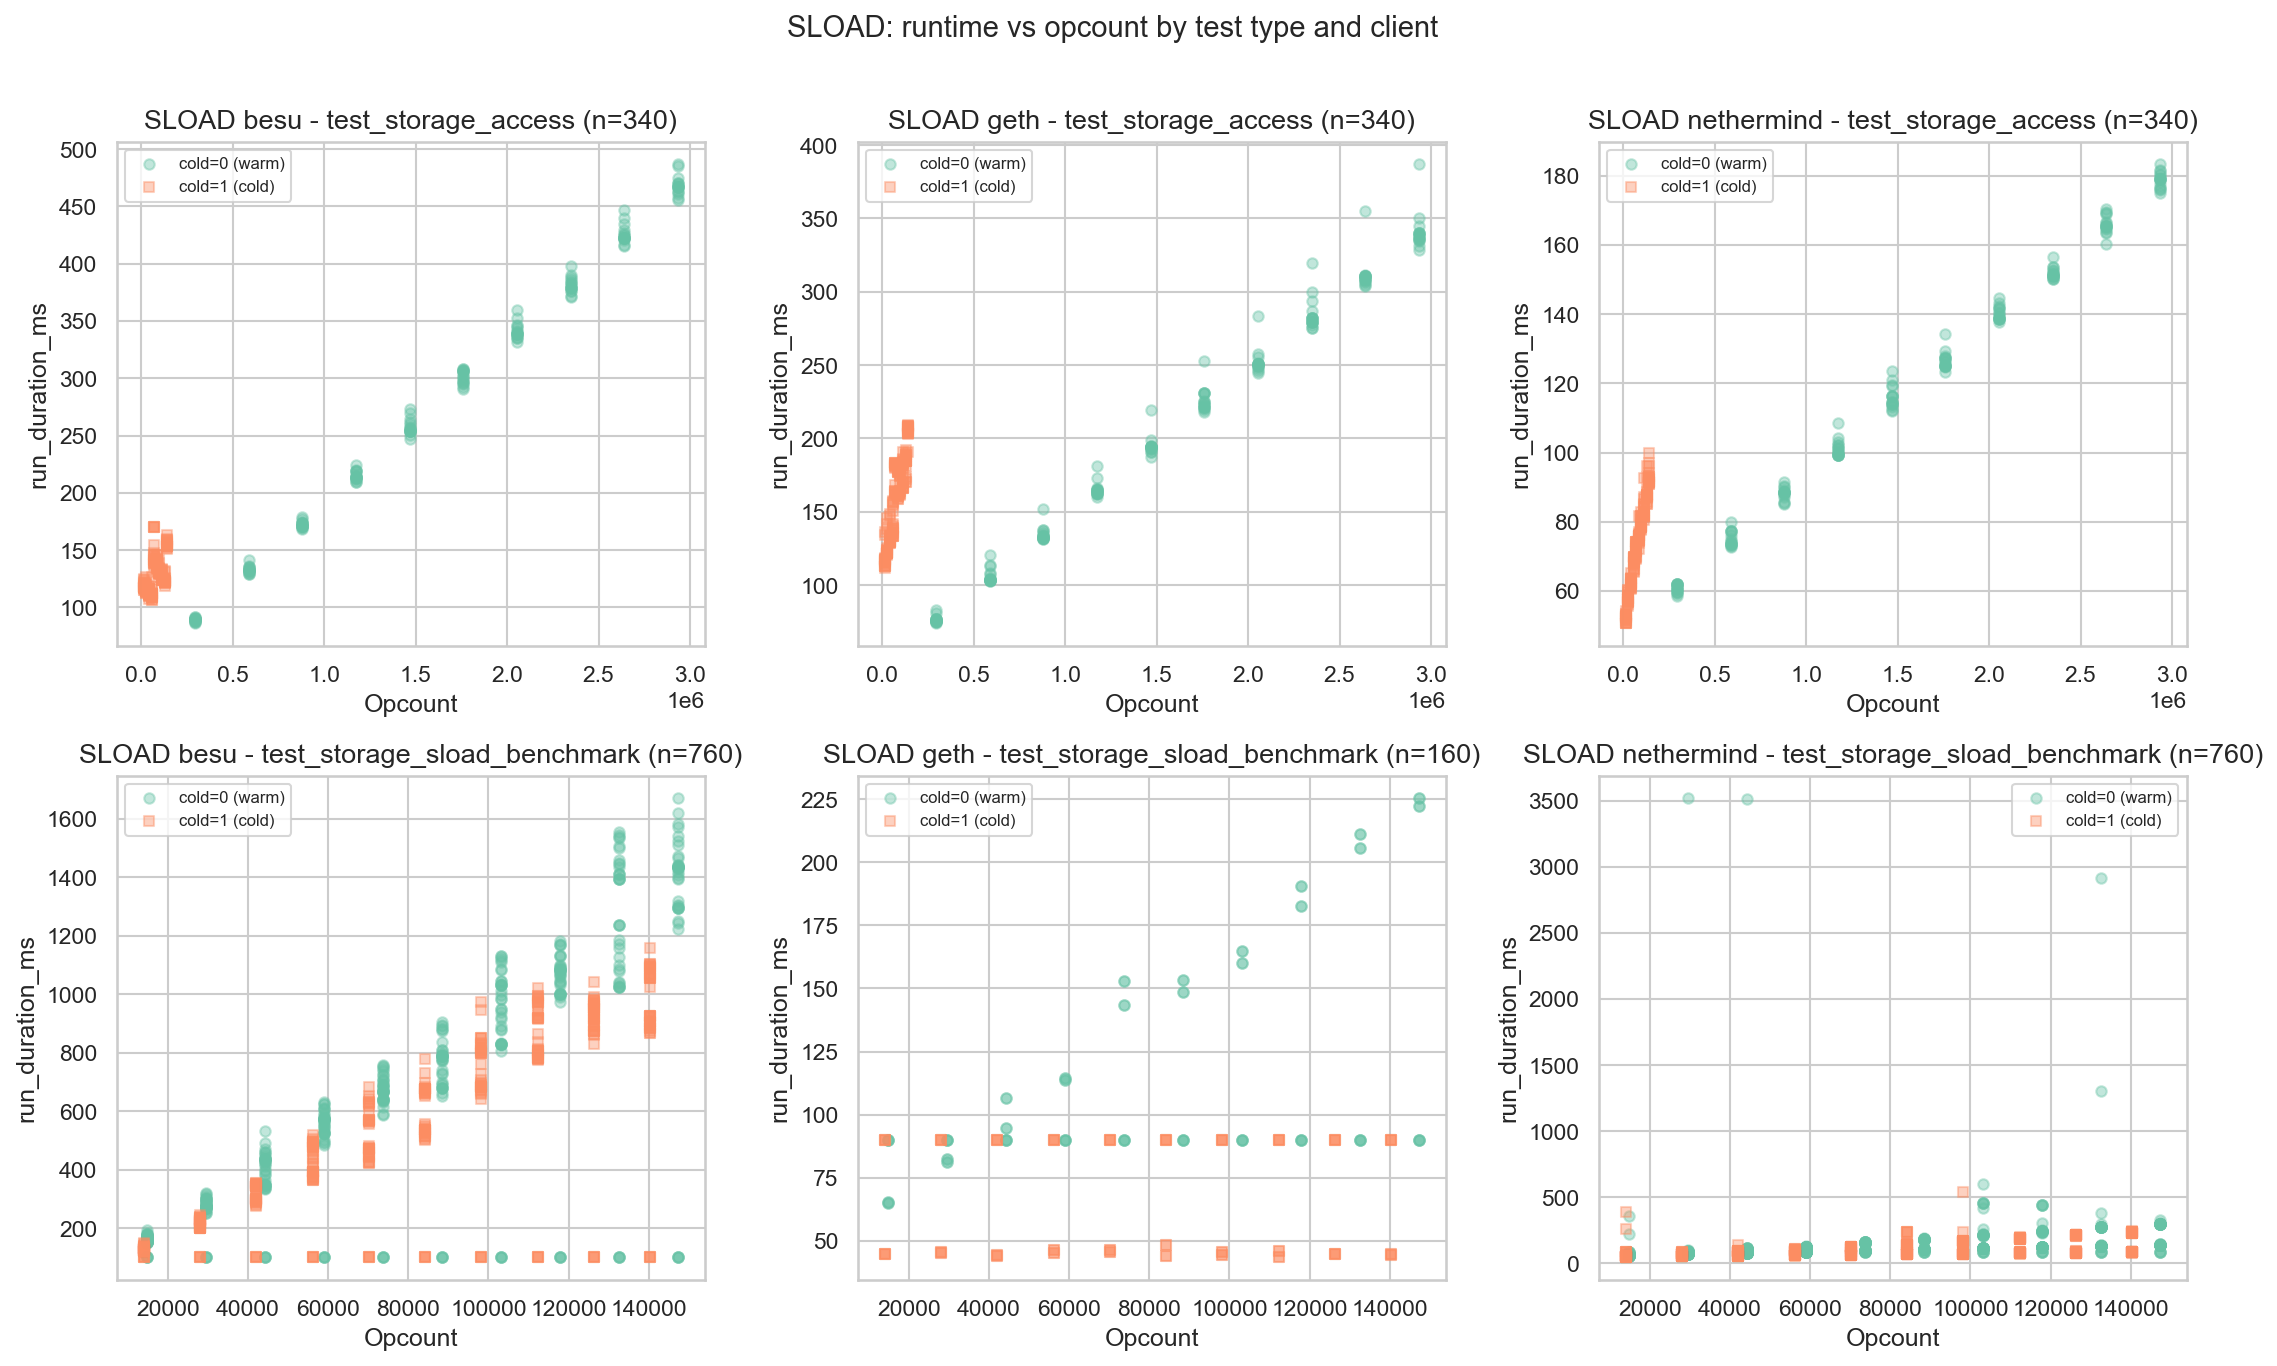

In [5]:
# SLOAD runtime by client, test_name, and cold/warm
sload_df["cold"] = sload_df["test_params"].apply(lambda x: extract_param_values(str(x), "cold"))
sload_df["cold_label"] = sload_df["cold"].map({"0": "warm", "1": "cold"})
sload_df["source"] = np.where(
    sload_df["test_name"].str.contains("test_storage_access", na=False),
    "test_storage_access", "benchmark"
)

clients = sorted(sload_df["client_name"].unique())
test_names = sorted(sload_df["test_name"].unique())
n_tests = len(test_names)

fig, axes = plt.subplots(n_tests, len(clients), figsize=(5 * len(clients), 4.5 * n_tests),
                          squeeze=False)

for row, tn in enumerate(test_names):
    for col, client in enumerate(clients):
        ax = axes[row][col]
        subset = sload_df[(sload_df["client_name"] == client) & (sload_df["test_name"] == tn)]
        for cold_val, color, marker in [("0", "C0", "o"), ("1", "C1", "s")]:
            pts = subset[subset["cold"] == cold_val]
            label_str = f"cold={cold_val} ({'warm' if cold_val == '0' else 'cold'})"
            ax.scatter(pts["opcount"], pts["run_duration_ms"],
                       c=color, marker=marker, alpha=0.4, s=25, label=label_str)
        ax.set_xlabel("Opcount")
        ax.set_ylabel("run_duration_ms")
        ax.set_title(f"SLOAD {client} - {tn} (n={len(subset)})")
        ax.legend(fontsize=8)

plt.suptitle("SLOAD: runtime vs opcount by test type and client", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

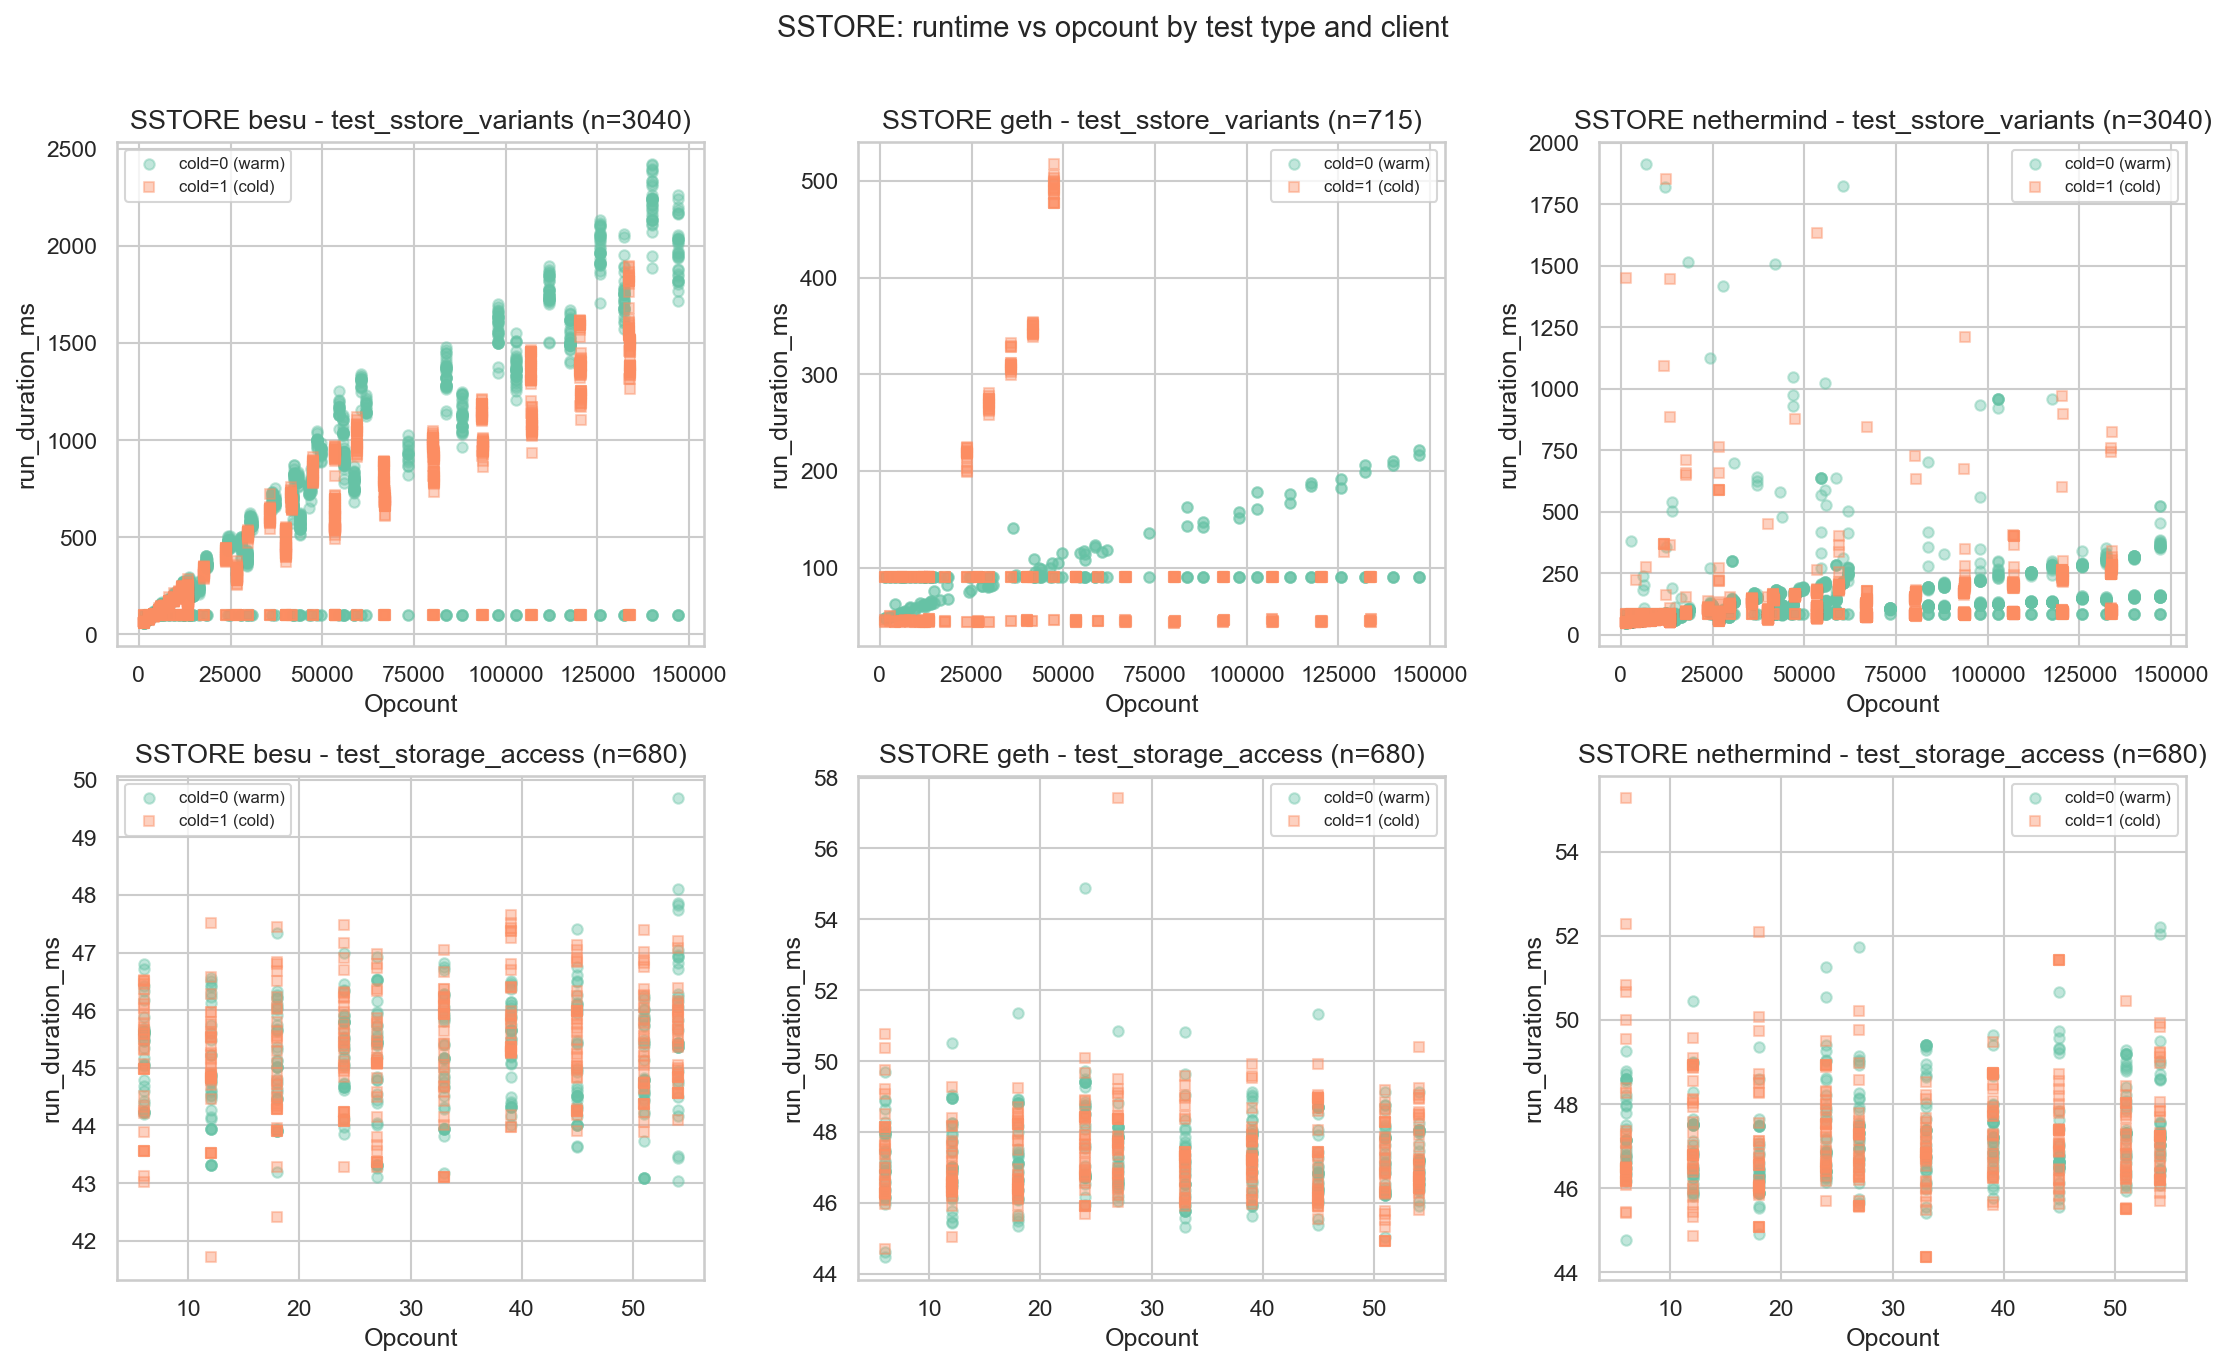

In [6]:
# SSTORE runtime by client, test_name, and cold/warm
sstore_df["cold"] = sstore_df["test_params"].apply(lambda x: extract_param_values(str(x), "cold"))
sstore_df["new"] = sstore_df["test_params"].apply(lambda x: extract_param_values(str(x), "new"))
sstore_df["update"] = sstore_df["test_params"].apply(lambda x: extract_param_values(str(x), "update"))
sstore_df["source"] = np.where(
    sstore_df["test_name"].str.contains("test_storage_access", na=False),
    "test_storage_access", "sstore_variants"
)

clients = sorted(sstore_df["client_name"].unique())
test_names = sorted(sstore_df["test_name"].unique())
n_tests = len(test_names)

fig, axes = plt.subplots(n_tests, len(clients), figsize=(5 * len(clients), 4.5 * n_tests),
                          squeeze=False)

for row, tn in enumerate(test_names):
    for col, client in enumerate(clients):
        ax = axes[row][col]
        subset = sstore_df[(sstore_df["client_name"] == client) & (sstore_df["test_name"] == tn)]
        for cold_val, color, marker in [("0", "C0", "o"), ("1", "C1", "s")]:
            pts = subset[subset["cold"] == cold_val]
            label_str = f"cold={cold_val} ({'warm' if cold_val == '0' else 'cold'})"
            ax.scatter(pts["opcount"], pts["run_duration_ms"],
                       c=color, marker=marker, alpha=0.4, s=25, label=label_str)
        ax.set_xlabel("Opcount")
        ax.set_ylabel("run_duration_ms")
        ax.set_title(f"SSTORE {client} - {tn} (n={len(subset)})")
        ax.legend(fontsize=8)

plt.suptitle("SSTORE: runtime vs opcount by test type and client", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Geth SLOAD anomaly: cold_1 runtime is flat

For the benchmark test, geth cold_1 (cold) runtime is constant at ~67ms regardless of opcount.

In [7]:
# Flat runtime analysis for geth
geth_sload = sload_df[sload_df["client_name"] == "geth"]

for tn in sorted(geth_sload["test_name"].unique()):
    tn_df = geth_sload[geth_sload["test_name"] == tn]
    print(f"\n=== Geth SLOAD: {tn} ===")
    stats = (
        tn_df.groupby(["test_params", "opcount"])["run_duration_ms"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    for params in sorted(stats["test_params"].unique()):
        p_stats = stats[stats["test_params"] == params].sort_values("opcount")
        cold_val = extract_param_values(params, "cold")
        label = "warm" if cold_val == "0" else "cold"
        mean_range = f"{p_stats['mean'].min():.1f} - {p_stats['mean'].max():.1f}ms"
        std_of_means = p_stats["mean"].std()
        scaling = "FLAT" if std_of_means < 2.0 else "scales with opcount"
        print(f"  {params} ({label}): mean range={mean_range}, std_of_means={std_of_means:.2f}ms -> {scaling}")


=== Geth SLOAD: test_storage_access ===
  cold_0 (warm): mean range=76.5 - 340.8ms, std_of_means=89.08ms -> scales with opcount
  cold_1 (cold): mean range=117.8 - 205.3ms, std_of_means=28.59ms -> scales with opcount

=== Geth SLOAD: test_storage_sload_benchmark ===
  cold_0 (warm): mean range=77.6 - 156.8ms, std_of_means=26.65ms -> scales with opcount
  cold_1 (cold): mean range=67.1 - 68.1ms, std_of_means=0.32ms -> FLAT


## 6. SSTORE variant analysis

The SSTORE benchmark produces meaningfully different opcounts for `update` variants.
Let's check per-variant regression slopes.

In [8]:
# SSTORE opcounts by variant
sstore_opcount_summary = (
    sstore_df.groupby(["test_name", "test_params"])["opcount"]
    .agg(["min", "max", "nunique", "count"])
    .sort_values(["test_name", "max"], ascending=[True, False])
)
sstore_opcount_summary["implied_gas_per_op"] = (300e6 / sstore_opcount_summary["max"]).round(0)
print("SSTORE opcounts by test and variant:")
display(sstore_opcount_summary)

SSTORE opcounts by test and variant:


min       max  nunique  count  \
test_name            test_params                                                
test_sstore_variants new_1-update_0-cold_0  13978.0  146921.0       20    840   
                     new_0-update_0-cold_0  13978.0  146920.0       20    840   
                     new_1-update_0-cold_1  13373.0  134055.0       20    840   
                     new_0-update_0-cold_1  13373.0  134054.0       20    840   
                     new_0-update_1-cold_0   6063.0   61958.0       20    840   
                     new_0-update_1-cold_1   5943.0   59506.0       20    915   
                     new_1-update_1-cold_0   1358.0   13657.0       20    840   
                     new_1-update_1-cold_1   1353.0   13535.0       18    840   
test_storage_access  cold_0-new_0-update_1      6.0      54.0       10    510   
                     cold_0-new_1-update_1      6.0      54.0       10    510   
                     cold_1-new_0-update_1      6.0      54.0       10    510   
                     cold_1-new_1-update_1      6.0      54.0       10    510   

                                            implied_gas_per_op  
test_name            test_params                                
test_sstore_variants new_1-update_0-cold_0              2042.0  
                     new_0-update_0-cold_0              2042.0  
                     new_1-update_0-cold_1              2238.0  
                     new_0-update_0-cold_1              2238.0  
                     new_0-update_1-cold_0              4842.0  
                     new_0-update_1-cold_1              5042.0  
                     new_1-update_1-cold_0             21967.0  
                     new_1-update_1-cold_1             22165.0  
test_storage_access  cold_0-new_0-update_1           5555556.0  
                     cold_0-new_1-update_1           5555556.0  
                     cold_1-new_0-update_1           5555556.0  
                     cold_1-new_1-update_1           5555556.0

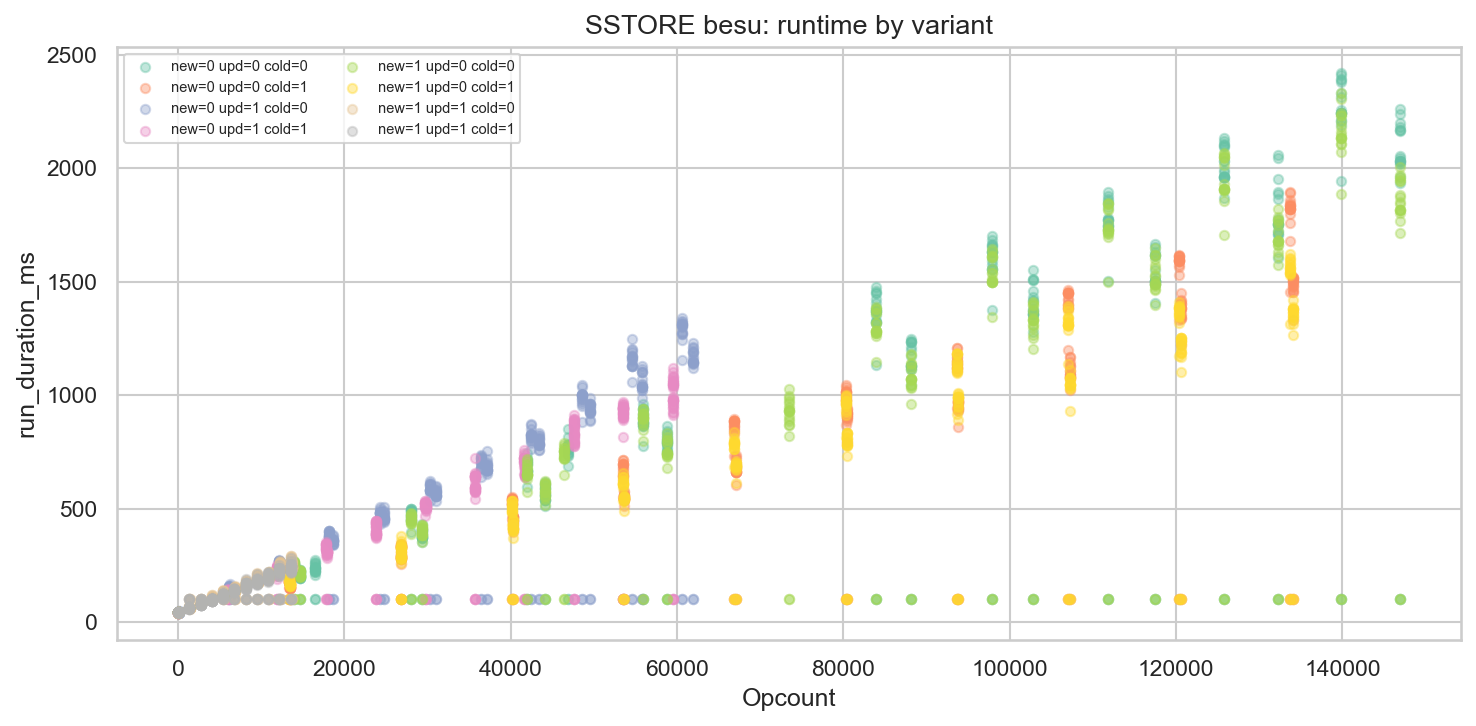


Besu SSTORE: per-variant linear regression
Variant                                   Slope (ms/op)       R²     n
---------------------------------------------------------------------------
new=0 upd=0 cold=0                             0.013219    0.689   380
new=0 upd=0 cold=1                             0.010828    0.667   380
new=0 upd=1 cold=0                             0.017009    0.816   550
new=0 upd=1 cold=1                             0.014733    0.822   550
new=1 upd=0 cold=0                             0.012281    0.649   380
new=1 upd=0 cold=1                             0.009508    0.658   380
new=1 upd=1 cold=0                             0.014394    0.897   550
new=1 upd=1 cold=1                             0.013430    0.905   550

Different variants have DIFFERENT slopes -> parameter effects exist.


In [9]:
# Per-variant slopes for besu (cleanest client)
besu_sstore = sstore_df[sstore_df["client_name"] == "besu"].dropna(subset=["opcount"]).copy()

if len(besu_sstore) > 0:
    besu_sstore["variant"] = (
        "new=" + besu_sstore["new"].fillna("?") +
        " upd=" + besu_sstore["update"].fillna("?") +
        " cold=" + besu_sstore["cold"].fillna("?")
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    for variant in sorted(besu_sstore["variant"].unique()):
        subset = besu_sstore[besu_sstore["variant"] == variant]
        ax.scatter(subset["opcount"], subset["run_duration_ms"], alpha=0.4, s=20, label=variant)
    ax.set_xlabel("Opcount")
    ax.set_ylabel("run_duration_ms")
    ax.set_title("SSTORE besu: runtime by variant")
    ax.legend(fontsize=7, ncol=2, loc="upper left")
    plt.tight_layout()
    plt.show()

    print("\nBesu SSTORE: per-variant linear regression")
    print(f"{'Variant':<40} {'Slope (ms/op)':>14} {'R\u00b2':>8} {'n':>5}")
    print("-" * 75)
    for variant in sorted(besu_sstore["variant"].unique()):
        subset = besu_sstore[besu_sstore["variant"] == variant].dropna(subset=["opcount", "run_duration_ms"])
        if len(subset) > 2:
            slope, intercept, r, p, se = linregress(subset["opcount"], subset["run_duration_ms"])
            print(f"{variant:<40} {slope:>14.6f} {r**2:>8.3f} {len(subset):>5}")
    print("\nDifferent variants have DIFFERENT slopes -> parameter effects exist.")

## 7. Noise analysis: Nethermind outliers and Geth data scarcity

In [10]:
# Data availability
print("=== Observations per client ===")
for op_name, op_df in [("SLOAD", sload_df), ("SSTORE", sstore_df)]:
    print(f"\n{op_name}:")
    counts = op_df["client_name"].value_counts()
    timestamps = op_df.groupby("client_name")["ingestion_timestamp"].nunique()
    nan_counts = op_df.groupby("client_name")["opcount"].apply(lambda x: x.isna().sum())
    for client in sorted(counts.index):
        print(f"  {client}: {counts[client]} rows, {timestamps[client]} timestamps, "
              f"{nan_counts[client]} NaN opcounts")

=== Observations per client ===

SLOAD:
  besu: 1100 rows, 35 timestamps, 0 NaN opcounts
  geth: 500 rows, 20 timestamps, 0 NaN opcounts
  nethermind: 1100 rows, 35 timestamps, 0 NaN opcounts

SSTORE:
  besu: 3720 rows, 35 timestamps, 0 NaN opcounts
  geth: 1395 rows, 35 timestamps, 0 NaN opcounts
  nethermind: 3720 rows, 35 timestamps, 0 NaN opcounts


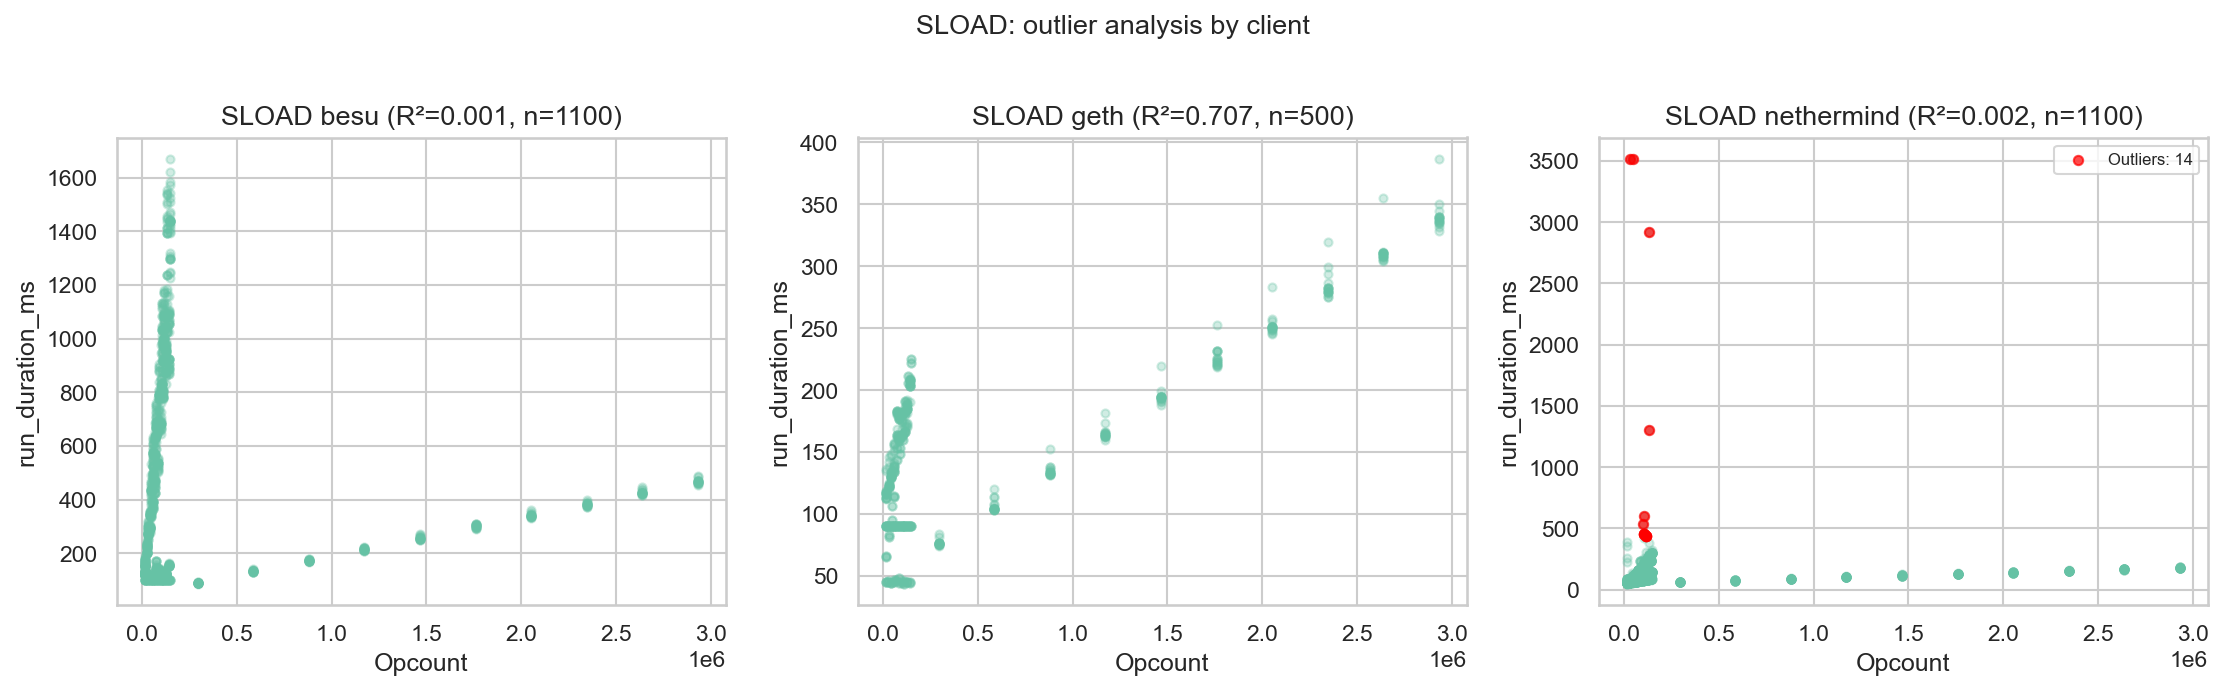

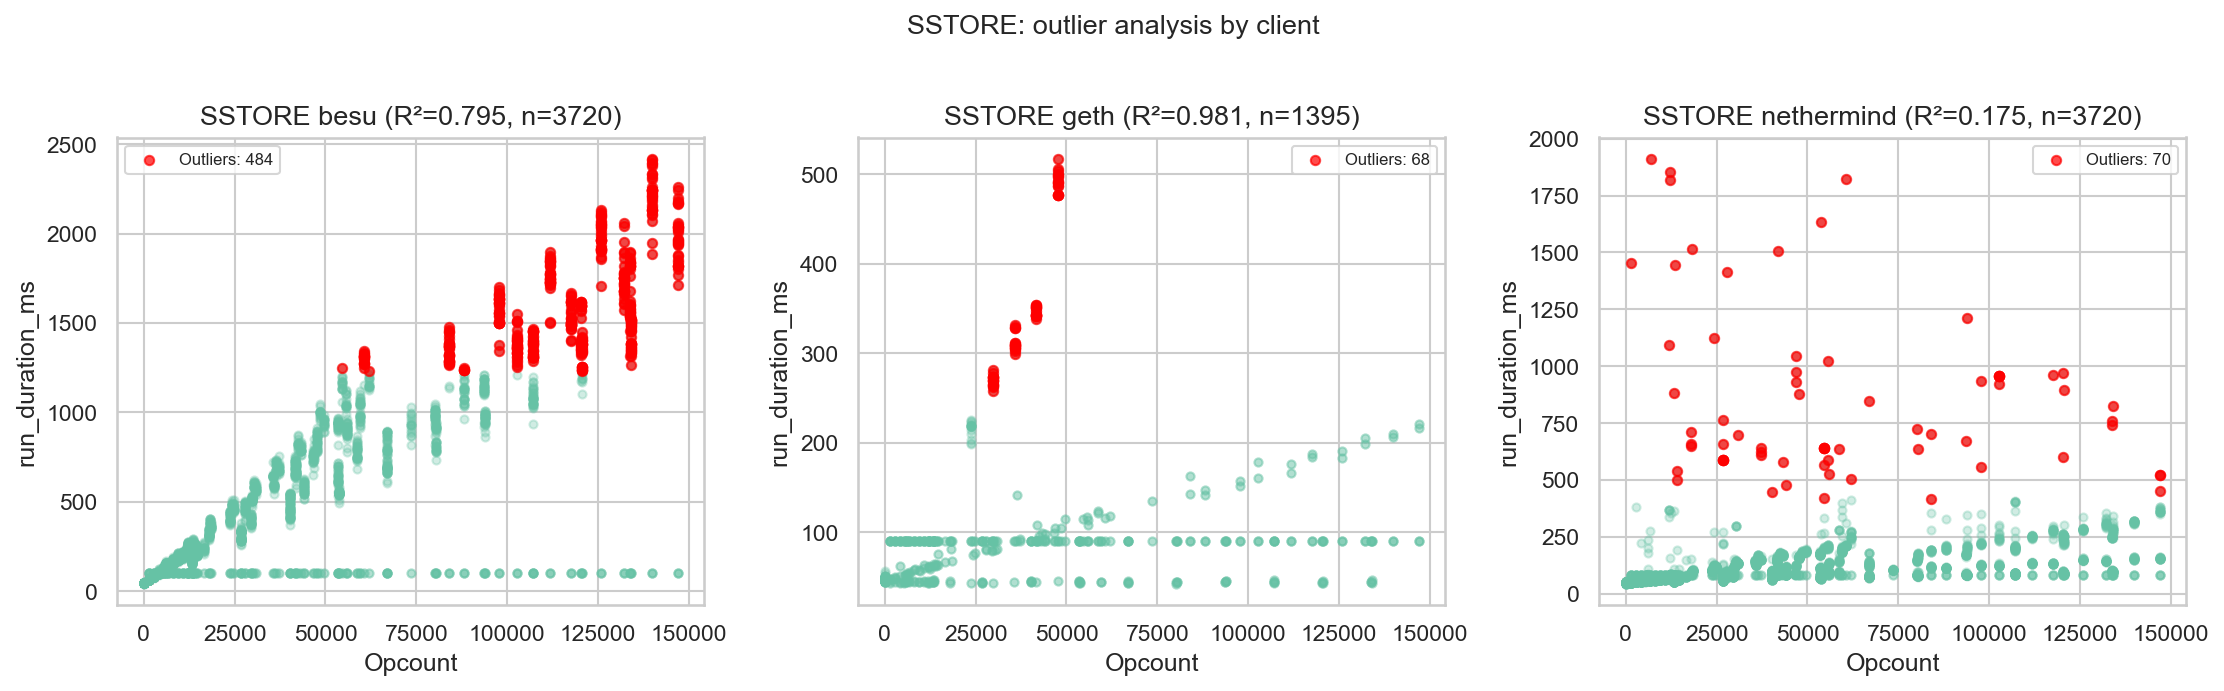

In [11]:
# Outlier analysis across all clients
for op_name, op_df in [("SLOAD", sload_df), ("SSTORE", sstore_df)]:
    clients = sorted(op_df["client_name"].unique())
    fig, axes = plt.subplots(1, len(clients), figsize=(5 * len(clients), 4.5))
    if len(clients) == 1:
        axes = [axes]

    for i, client in enumerate(clients):
        ax = axes[i]
        client_df = op_df[op_df["client_name"] == client].dropna(subset=["opcount"])
        ax.scatter(client_df["opcount"], client_df["run_duration_ms"], alpha=0.3, s=15)

        median_rt = client_df["run_duration_ms"].median()
        outliers = client_df[client_df["run_duration_ms"] > 5 * median_rt]
        if len(outliers) > 0:
            ax.scatter(outliers["opcount"], outliers["run_duration_ms"],
                       c="red", s=20, alpha=0.7, label=f"Outliers: {len(outliers)}")

        r2_vals = results_df[(results_df["client"] == client) & (results_df["opcode"] == op_name)]["rsquared"]
        r2_str = f"R\u00b2={r2_vals.values[0]:.3f}" if len(r2_vals) > 0 else ""
        ax.set_xlabel("Opcount")
        ax.set_ylabel("run_duration_ms")
        ax.set_title(f"{op_name} {client} ({r2_str}, n={len(client_df)})")
        if len(outliers) > 0:
            ax.legend(fontsize=8)

    plt.suptitle(f"{op_name}: outlier analysis by client", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Model Results

In [12]:
# Current model results
display_cols = ["opcode", "client", "nobs", "rsquared", "rsquared_adj", "intercept", "slope", "slope_pvalue"]
param_cols = [c for c in results_df.columns if any(p in c for p in ["new", "cold", "update"]) and "conf" not in c]
display_cols += param_cols
display_cols = [c for c in display_cols if c in results_df.columns]

print("=== Model results for SLOAD and SSTORE ===")
display(results_df[display_cols].round(4))

=== Model results for SLOAD and SSTORE ===


,opcode,client,nobs,rsquared,rsquared_adj,intercept,slope,slope_pvalue,new,new_pvalue,cold,cold_pvalue,update,update_pvalue
0,SSTORE,geth,475,0.9814,0.9813,45.4251,0.0081,0.000,0.0418,0.0,0.0000,1.000,0.0000,1.0
1,SSTORE,nethermind,3720,0.1754,0.1745,55.0977,0.0012,0.000,0.0000,1.0,0.0000,1.000,0.0017,0.0
2,SSTORE,besu,3720,0.7954,0.7952,31.0514,0.0115,0.000,0.0000,1.0,0.0000,1.000,0.0046,0.0
3,SLOAD,geth,500,0.7070,0.7058,91.7662,0.0001,0.000,NaN,NaN,0.0004,0.000,NaN,NaN
4,SLOAD,nethermind,1100,0.0018,-0.0000,120.5389,0.0000,0.003,NaN,NaN,0.0000,1.000,NaN,NaN
5,SLOAD,besu,1100,0.0009,-0.0010,475.5504,0.0000,1.000,NaN,NaN,0.0002,0.187,NaN,NaN


## Summary of Findings

### SLOAD

| Test | Cold/Warm Differentiation | Notes |
|---|---|---|
| `test_storage_access` | **Works**: 20.58x opcount ratio (expected ~21x) | Implied gas/op: warm=102, cold=2,105 |
| `test_storage_sload_benchmark` | **Broken**: 1.05x ratio | warm/cold produce nearly identical opcounts |

**`test_storage_sload_benchmark` issues:**
- The `access_warm` flag has no effect on opcounts — cold and warm variants are indistinguishable
- Geth cold=1 runtime is completely flat (std of means = 0.32ms across all opcounts), suggesting the cold access path is cached or short-circuited
- Model R² is near zero for besu (0.001) and nethermind (0.002); geth achieves R²=0.71 only because `test_storage_access` contributes meaningful variation

**`test_storage_access` works correctly for SLOAD:**
- Provides clear cold/warm separation with expected ~21x opcount ratio
- Runtime scales with opcount for all three clients
- Devnet cross-validation confirms the same 20.58x ratio, ruling out machine-specific effects

### SSTORE

| Test | Cold/Warm Differentiation | Notes |
|---|---|---|
| `test_sstore_variants` | **`cold` broken** (1.10x ratio), **`update` works** (2x–10x) | `new` param has no opcount effect |
| `test_storage_access` | **Broken**: all variants have identical opcounts (6–54) | Implied gas/op ~5.6M — far too low opcount to be useful |

**`test_sstore_variants` details:**
- The `update` parameter produces meaningfully different opcounts: `update=0` yields ~147k max ops vs `update=1` at ~62k (update=0, new=0) or ~14k (update=1, new=1)
- The `cold` parameter is broken: cold_0/cold_1 opcounts differ by only ~10%, same issue as the SLOAD benchmark
- The `new` parameter has no independent effect on opcounts (new=0 and new=1 produce identical opcounts within each update/cold combination)
- Per-variant regressions confirm that different variants do have different slopes, so parameter effects on runtime exist — they're just not captured by the cold flag
- Model R² is good for geth (0.98) and decent for besu (0.80), but poor for nethermind (0.18) due to extreme outliers

**`test_storage_access` is unusable for SSTORE:**
- Opcounts are extremely low (6–54) across all parameter combinations
- No differentiation between cold/warm or new/existing variants

### Cross-cutting issues

| Issue | Affected | Evidence |
|---|---|---|
| Nethermind outliers | SSTORE | Runtimes up to ~3,500ms at low opcounts (system noise) |
| Geth data scarcity | SLOAD | Only 500 rows (20 ingestion timestamps) vs 1,100 for other clients |
| `cold` flag ineffective | Both SLOAD benchmark + SSTORE variants | All model `cold` coefficients are 0 or near-zero with p-values = 1.0 |

### Recommendations
1. **Fix the cold/warm flag** in `test_storage_sload_benchmark` and `test_sstore_variants` — the benchmarks do not actually vary the cold-access cost
2. **Use `test_storage_access` for SLOAD** — it already provides correct cold/warm differentiation (21x ratio)
3. **Fix or replace `test_storage_access` for SSTORE** — current opcounts (6–54) are too low to produce meaningful regressions
4. **Add outlier filtering for Nethermind** — extreme runtime spikes at low opcounts degrade SSTORE model fits
5. **Accumulate more Geth SLOAD data** — 500 rows from 20 timestamps is thin compared to 1,100 rows for besu/nethermind